# Chess Position Evaluation Model

this is the notebook used to build the chess board position evaluation model that i need for my ML chess engine personal project.

## 1. Download the Lichess evaluations dataset

this sections downloads the Lichess evaluation dataset and saves it into a csv file so that it can be uploaded anytime the runtime disconnects (completing this in google colab). this section only need to be run once.

In [ ]:
# !pip install -q zstandard

In [ ]:
# url = "https://database.lichess.org/lichess_db_eval.jsonl.zst"
# file_path = "/content/lichess_db_eval.jsonl.zst"

# !wget -c "$url" -O "$file_path"

In [ ]:
# import json
# import io
# import pandas as pd
# import zstandard as zstd

In [ ]:
# row_limit = 500_000
# rows = []

# with open(file_path, "rb") as compressed_file:
#     decompressor = zstd.ZstdDecompressor()

#     with decompressor.stream_reader(compressed_file) as reader:
#         text_reader = io.TextIOWrapper(reader, encoding="utf-8")

#         for line_number, line in enumerate(text_reader):
#             if line_number >= row_limit:
#                 break

#             position = json.loads(line)

#             best_eval = max(
#                 position["evals"],
#                 key=lambda evaluation: evaluation["depth"]
#             )

#             best_pv = best_eval["pvs"][0]

#             row = {
#                 "fen": position["fen"],
#                 "depth": best_eval["depth"],
#                 "knodes": best_eval["knodes"],
#                 "centipawn": best_pv.get("cp"),
#                 "mate": best_pv.get("mate"),
#                 "best_line": best_pv.get("line")
#             }

#             rows.append(row)

# print(f"Loaded {len(rows):,} positions")

In [ ]:
# df = pd.DataFrame(rows)

In [ ]:
# df.shape

In [ ]:
# csv_path = "/content/lichess_evaluations_500k.csv"

# df.to_csv(csv_path, index=False)

## 2. Environment and configuration

In [ ]:
!pip install -q python-chess==1.999

In [ ]:
import hashlib
import json
import os
import time
from pathlib import Path

import chess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from tqdm.auto import tqdm

SEED = 333
CSV_PATH = Path("/content/lichess_evaluations_500k.csv")
CHECKPOINT_PATH = Path("/content/chess_evaluator_training.pt")
FINAL_MODEL_PATH = Path("/content/chess_evaluator_v1.pt")
CP_CLIP = 2000
CP_SCALE = 400
BATCH_SIZE = 512
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 3. Load and validate positions

In [ ]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Upload the dataset to {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
required_columns = {"fen", "centipawn", "mate"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

print("Raw rows:", len(df))
df.head()

Raw rows: 500000


,fen,depth,knodes,centipawn,mate,best_line
0,7r/1p3k2/p1bPR3/5p2/2B2P1p/8/PP4P1/3K4 b - -,46,4189972,69.0,NaN,f7g7 e6e2 h8d8 e2d2 b7b5 c4b3 g7f6 d1e1 a6a5 a2a3
1,8/4r3/2R2pk1/6pp/3P4/6P1/5K1P/8 b - -,58,491568,0.0,NaN,e7a7 f2e3 a7a3 e3e4 a3a2 h2h4 g5h4 g3h4 a2h2 c6c1
2,6k1/6p1/8/4K3/4NN2/8/8/8 w - -,95,589893,NaN,15.0,e5e6 g8f8 e4d6 g7g5 f4h5 g5g4 h5g3 f8g8 e6e7 g8g7
3,r1b2rk1/1p2bppp/p1nppn2/q7/2P1P3/N1N5/PP2BPPP/...,40,4168028,24.0,NaN,f1e1 f8d8 c1d2 a5b6 a3c2 d6d5 e4d5 e6d5 c3d5 f6d5
4,6k1/4Rppp/8/8/8/8/5PPP/6K1 w - -,245,157,NaN,1.0,e7e8


In [ ]:
def parse_board(fen):
    return chess.Board(f"{fen} 0 1")

def is_valid_position(fen):
    try:
        return parse_board(fen).is_valid()
    except ValueError:
        return False

valid_mask = df["fen"].map(is_valid_position)
print("Valid rows:", int(valid_mask.sum()))
print("Removed rows:", int((~valid_mask).sum()))

df = df.loc[valid_mask].reset_index(drop=True)

Valid rows: 497487
Removed rows: 2513


## 4. Targets and deterministic splits

In [ ]:
cp_target = np.tanh(df["centipawn"].clip(-CP_CLIP, CP_CLIP) / CP_SCALE)
mate_target = np.sign(df["mate"])
df["target"] = cp_target.where(df["centipawn"].notna(), mate_target).astype("float32")

if df["target"].isna().any():
    raise ValueError("Every row must contain either a centipawn or mate label")

def split_bucket(fen):
    digest = hashlib.sha256(fen.encode()).digest()
    return int.from_bytes(digest[:8], "big") % 100

buckets = df["fen"].map(split_bucket)
df["split"] = np.select(
    [buckets < 80, buckets < 90],
    ["train", "validation"],
    default="test",
)

print(df["target"].describe())
print(df["split"].value_counts())

count    497487.000000
mean          0.193144
std           0.546815
min          -1.000000
25%          -0.027493
50%           0.072373
75%           0.694967
max           1.000000
Name: target, dtype: float64
split
train         398160
test           49820
validation     49507
Name: count, dtype: int64


## 4. Encode positions

In [ ]:
def encode_position(fen):
    board = parse_board(fen)
    encoded = np.zeros((18, 8, 8), dtype=np.uint8)

    for square, piece in board.piece_map().items():
        color_offset = 0 if piece.color == chess.WHITE else 6
        channel = color_offset + piece.piece_type - 1
        row = 7 - chess.square_rank(square)
        column = chess.square_file(square)
        encoded[channel, row, column] = 1

    encoded[12, :, :] = int(board.turn == chess.WHITE)
    encoded[13, :, :] = int(board.has_kingside_castling_rights(chess.WHITE))
    encoded[14, :, :] = int(board.has_queenside_castling_rights(chess.WHITE))
    encoded[15, :, :] = int(board.has_kingside_castling_rights(chess.BLACK))
    encoded[16, :, :] = int(board.has_queenside_castling_rights(chess.BLACK))

    if board.ep_square is not None:
        row = 7 - chess.square_rank(board.ep_square)
        column = chess.square_file(board.ep_square)
        encoded[17, row, column] = 1

    return encoded

X = np.empty((len(df), 18, 8, 8), dtype=np.uint8)
for index, fen in enumerate(tqdm(df["fen"], desc="Encoding positions")):
    X[index] = encode_position(fen)

y = df["target"].to_numpy(dtype=np.float32)
print(f"Encoded array: {X.shape}, {X.nbytes / 1024**2:.1f} MiB")

Encoding positions:   0%|          | 0/497487 [00:00<?, ?it/s]

Encoded array: (497487, 18, 8, 8), 546.6 MiB


## 5. Baselines and data loaders

In [ ]:
train_indices = np.flatnonzero(df["split"].eq("train"))
validation_indices = np.flatnonzero(df["split"].eq("validation"))
test_indices = np.flatnonzero(df["split"].eq("test"))

piece_values = np.array([100, 320, 330, 500, 900, 0], dtype=np.int16)
piece_counts = X[:, :12].sum(axis=(2, 3), dtype=np.int16)
material_difference = piece_counts[:, :6] - piece_counts[:, 6:]
material_cp = (material_difference * piece_values).sum(axis=1)
material_predictions = np.tanh(np.clip(material_cp, -CP_CLIP, CP_CLIP) / CP_SCALE)

train_median = float(np.median(y[train_indices]))
validation_median_mae = float(np.mean(np.abs(y[validation_indices] - train_median)))
validation_material_mae = float(np.mean(
    np.abs(material_predictions[validation_indices] - y[validation_indices])
))
print("Training-median validation MAE:", validation_median_mae)
print("Material validation MAE:", validation_material_mae)

Training-median validation MAE: 0.40957877039909363
Material validation MAE: 0.3153698516267786


In [ ]:
dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    Subset(dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True,
    generator=generator, num_workers=2, pin_memory=device.type == "cuda",
)
validation_loader = DataLoader(
    Subset(dataset, validation_indices), batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=device.type == "cuda",
)
test_loader = DataLoader(
    Subset(dataset, test_indices), batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=device.type == "cuda",
)

## 6. Model and training

In [ ]:
class ChessEvaluator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(18, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
        )

    def forward(self, positions):
        return self.head(self.features(positions)).squeeze(1)

In [ ]:
model = ChessEvaluator().to(device)
criterion = nn.HuberLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=1
)

sample_positions, _ = next(iter(validation_loader))
sample_positions = sample_positions.to(device, dtype=torch.float32)
model.eval()
with torch.no_grad():
    initial_predictions = model(sample_positions)

print("Initial prediction mean:", initial_predictions.mean().item())
print("Initial prediction std:", initial_predictions.std().item())
print("Initial prediction range:",
      initial_predictions.min().item(), initial_predictions.max().item())
if initial_predictions.std().item() < 1e-5:
    raise RuntimeError("Initial predictions have collapsed before training")

Initial prediction mean: -0.05679813399910927
Initial prediction std: 0.0032864415552467108
Initial prediction range: -0.06297648698091507 -0.047984831035137177


In [ ]:
def run_epoch(loader, training):
    model.train(training)
    loss_sum = mae_sum = count = 0

    with torch.set_grad_enabled(training):
        for positions, targets in loader:
            positions = positions.to(device, dtype=torch.float32, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            predictions = model(positions)
            loss = criterion(predictions, targets)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            batch_size = targets.size(0)
            loss_sum += loss.item() * batch_size
            mae_sum += torch.abs(predictions - targets).sum().item()
            count += batch_size

    return loss_sum / count, mae_sum / count

In [ ]:
best_validation_loss = float("inf")
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_mae = run_epoch(train_loader, True)
    validation_loss, validation_mae = run_epoch(validation_loader, False)
    scheduler.step(validation_loss)

    history.append({
        "epoch": epoch, "train_loss": train_loss, "train_mae": train_mae,
        "validation_loss": validation_loss, "validation_mae": validation_mae,
    })
    print(
        f"{epoch:02d}: train MAE={train_mae:.4f}, "
        f"validation MAE={validation_mae:.4f}, "
        f"lr={optimizer.param_groups[0]['lr']:.1e}"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "validation_loss": validation_loss,
        }, CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

01: train MAE=0.2903, validation MAE=0.2548, lr=3.0e-04
02: train MAE=0.2518, validation MAE=0.2396, lr=3.0e-04
03: train MAE=0.2357, validation MAE=0.2522, lr=3.0e-04
04: train MAE=0.2240, validation MAE=0.2235, lr=3.0e-04
05: train MAE=0.2151, validation MAE=0.2125, lr=3.0e-04
06: train MAE=0.2079, validation MAE=0.2122, lr=3.0e-04
07: train MAE=0.2018, validation MAE=0.2050, lr=3.0e-04
08: train MAE=0.1967, validation MAE=0.2069, lr=3.0e-04
09: train MAE=0.1923, validation MAE=0.1972, lr=3.0e-04
10: train MAE=0.1883, validation MAE=0.1974, lr=3.0e-04
11: train MAE=0.1845, validation MAE=0.1971, lr=3.0e-04
12: train MAE=0.1809, validation MAE=0.2062, lr=3.0e-04
13: train MAE=0.1787, validation MAE=0.1934, lr=3.0e-04
14: train MAE=0.1759, validation MAE=0.1945, lr=3.0e-04
15: train MAE=0.1731, validation MAE=0.1959, lr=1.5e-04


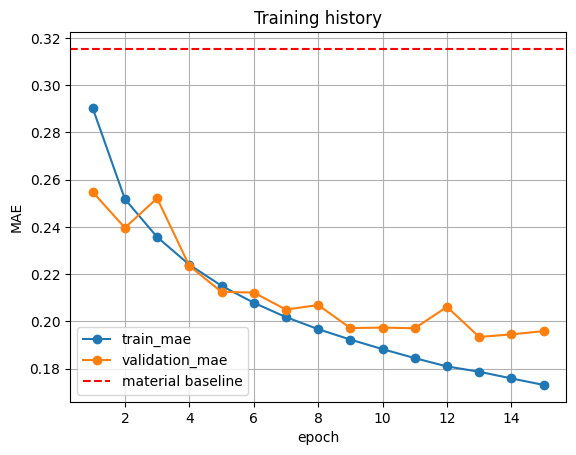

,epoch,train_loss,train_mae,validation_loss,validation_mae
0,1,0.085998,0.290324,0.068547,0.254776
1,2,0.066031,0.251802,0.062872,0.239636
2,3,0.058334,0.235721,0.064223,0.252150
3,4,0.052877,0.224020,0.055241,0.223550
4,5,0.048697,0.215078,0.049353,0.212504
5,6,0.045441,0.207911,0.048225,0.212230
6,7,0.042718,0.201821,0.046873,0.205008
7,8,0.040525,0.196732,0.046711,0.206938
8,9,0.038605,0.192303,0.043850,0.197197
9,10,0.036930,0.188272,0.043819,0.197373


In [ ]:
history_df = pd.DataFrame(history)
history_df.plot(
    x="epoch", y=["train_mae", "validation_mae"], marker="o",
    title="Training history", ylabel="MAE", grid=True,
)
plt.axhline(validation_material_mae, color="red", linestyle="--", label="material baseline")
plt.legend()
plt.show()
history_df

## 7. Final test evaluation

In [ ]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

prediction_batches = []
with torch.no_grad():
    for positions, _ in test_loader:
        positions = positions.to(device, dtype=torch.float32, non_blocking=True)
        prediction_batches.append(model(positions).cpu().numpy())

raw_predictions = np.concatenate(prediction_batches)
predictions = np.clip(raw_predictions, -1.0, 1.0)
test_targets = y[test_indices]
test_rows = df.iloc[test_indices].reset_index(drop=True)

test_mae = float(np.mean(np.abs(predictions - test_targets)))
test_material_mae = float(np.mean(
    np.abs(material_predictions[test_indices] - test_targets)
))
positive_mask = test_targets > 0.1
negative_mask = test_targets < -0.1
positive_accuracy = float(np.mean(predictions[positive_mask] > 0))
negative_accuracy = float(np.mean(predictions[negative_mask] < 0))
balanced_sign_accuracy = (positive_accuracy + negative_accuracy) / 2
mate_mask = test_rows["mate"].notna().to_numpy()
mate_sign_accuracy = float(np.mean(
    np.sign(predictions[mate_mask]) == np.sign(test_targets[mate_mask])
))

metrics = {
    "test_mae": test_mae,
    "material_test_mae": test_material_mae,
    "positive_sign_accuracy": positive_accuracy,
    "negative_sign_accuracy": negative_accuracy,
    "balanced_sign_accuracy": balanced_sign_accuracy,
    "mate_sign_accuracy": mate_sign_accuracy,
    "prediction_mean": float(predictions.mean()),
    "prediction_std": float(predictions.std()),
    "best_epoch": int(checkpoint["epoch"]),
}
print(json.dumps(metrics, indent=2))

{
  "test_mae": 0.18705500662326813,
  "material_test_mae": 0.31435840511924934,
  "positive_sign_accuracy": 0.9375356656863175,
  "negative_sign_accuracy": 0.7759222069548674,
  "balanced_sign_accuracy": 0.8567289363205924,
  "mate_sign_accuracy": 0.9778807668000843,
  "prediction_mean": 0.19606369733810425,
  "prediction_std": 0.45836642384529114,
  "best_epoch": 13
}


## 8. Qualification, export, and reload verification

In [ ]:
qualified = (
    test_mae < test_material_mae
    and positive_accuracy > 0.5
    and negative_accuracy > 0.5
    and np.isfinite(predictions).all()
)

print("Qualified for export:", qualified)
if not qualified:
    raise RuntimeError(
        "Model did not beat the required baselines. Do not integrate this checkpoint."
    )

model = model.cpu().eval()
torch.save({
    "model_state_dict": model.state_dict(),
    "input_channels": 18,
    "cp_clip": CP_CLIP,
    "cp_scale": CP_SCALE,
    "perspective": "white",
    "seed": SEED,
    "metrics": metrics,
}, FINAL_MODEL_PATH)
print(f"Saved {FINAL_MODEL_PATH} ({FINAL_MODEL_PATH.stat().st_size / 1024**2:.1f} MiB)")

Qualified for export: True
Saved /content/chess_evaluator_v1.pt (2.3 MiB)


In [ ]:
artifact = torch.load(FINAL_MODEL_PATH, map_location="cpu", weights_only=True)
reloaded_model = ChessEvaluator()
reloaded_model.load_state_dict(artifact["model_state_dict"])
reloaded_model.eval()

def evaluate_fen(fen):
    board = parse_board(fen)
    if not board.is_valid():
        raise ValueError("Position is not valid")

    tensor = torch.from_numpy(encode_position(fen)).unsqueeze(0).float()
    with torch.no_grad():
        return reloaded_model(tensor).clamp(-1, 1).item()

start_fen = " ".join(chess.STARTING_FEN.split()[:4])
first_prediction = evaluate_fen(start_fen)
second_prediction = evaluate_fen(start_fen)
assert first_prediction == second_prediction
print("Starting-position evaluation:", first_prediction)
print("Reload verification passed")

Starting-position evaluation: 0.07918955385684967
Reload verification passed
